In [21]:
import pandas as pd
import praw
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
import math
import numpy as np
import igraph as ig
import leidenalg
reddit = praw.Reddit("learning")
commentFrame = pd.read_pickle("comments.pkl")

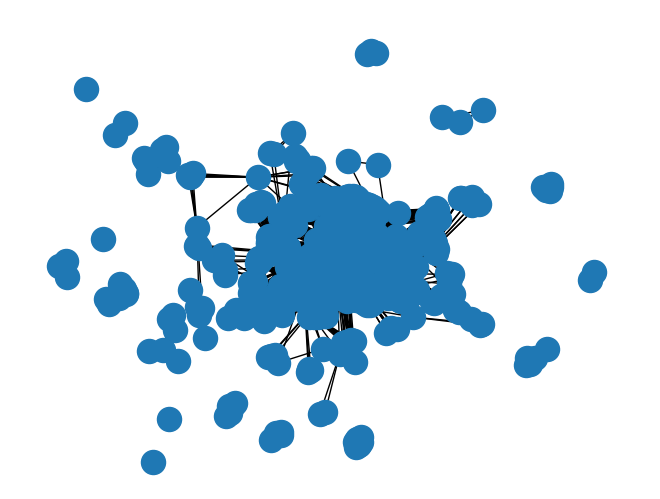

In [22]:
graph = nx.Graph()
graph.add_nodes_from(commentFrame["original post"].unique(), bipartite = 0)
graph.add_nodes_from(commentFrame["author"].unique(), bipartite = 1)#average weighted upvotes, average sentiment

author_upvotes = commentFrame.groupby("author")["upvoteScale"].mean().to_dict()

author_sentiment = (
    commentFrame.groupby("author")["AverageUserSentiment"].first().to_dict()
)

nx.set_node_attributes(graph, author_upvotes, "avg_upvotes")
nx.set_node_attributes(graph, author_sentiment, "avg_sentiment")
edges = zip(
    commentFrame["author"],
    commentFrame["original post"],
    commentFrame["body"],
    commentFrame["upvoteScale"]
)
graph.add_edges_from((a, b, {"body": c, "upvotes": d}) for a, b, c, d in edges)

uniqueUsers = [node for node, dic in graph.nodes(data = True) if dic["bipartite"] == 1]
biGraph = bipartite.weighted_projected_graph(graph, uniqueUsers)
nx.draw(biGraph)

In [27]:
print(biGraph.number_of_nodes())
print(biGraph.number_of_edges())
userGraph = biGraph.copy()
edges_to_remove = [(u,v) for u, v, d in biGraph.edges(data = True) if d["weight"] <= 1]
userGraph.remove_edges_from(edges_to_remove)

isolates = list(nx.isolates(userGraph))
userGraph.remove_nodes_from(isolates)

2524
401415


In [30]:
fullGraph = nx.Graph()
fullGraph.add_nodes_from(userGraph)

for u, v, data in userGraph.edges(data = True):
    raw_weight = data.get("weight", 1)

    deg_u = userGraph.degree(u, weight = "weight")
    deg_v = userGraph.degree(v, weight  = "weight")
    normalized = raw_weight / math.sqrt(deg_u * deg_v) if deg_u > 0 and deg_v > 0 else 0
    fullGraph.add_edge(deg_u, deg_v, weight = normalized)

components = nx.connected_components(fullGraph)
giant_component = max(components, key = len)
G_Giant = fullGraph.subgraph(giant_component)

In [31]:
fullgraph = G_Giant.copy()
nodeList = list(fullgraph.nodes())
edges = [(nodeList.index(u), nodeList.index(v)) for u, v in fullgraph.edges()]

g = ig.Graph(edges = edges, directed = False)

if nx.get_edge_attributes(fullgraph, "weight"):
    g.es["weight"] = [fullgraph[u][v].get("weight", 1.0) for u, v in fullgraph.edges()]

partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)

# Number of communities
print("Num communities:", len(partition))

# List nodes per community
for i, comm in enumerate(partition):
    print(f"Community {i}: {comm}")

# Modularity score
print("Modularity:", partition.quality())

Num communities: 5
Community 0: [9, 10, 11, 12, 13, 25, 27]
Community 1: [6, 16, 18, 19, 20, 23, 28]
Community 2: [14, 15, 17, 21, 22, 24, 26]
Community 3: [3, 4, 5, 7, 8]
Community 4: [0, 1, 2]
Modularity: 0.2579915077711905


In [26]:
G = userGraph.copy()
n = G.number_of_nodes()
percent = n/biGraph.number_of_nodes() * 100
m = G.number_of_edges()
density = nx.density(G)
components = list(nx.connected_components(G)) if not G.is_directed() else list(nx.weakly_connected_components(G))
num_components = len(components)
giant_size = max(len(c) for c in components) if components else 0
avg_degree = sum(dict(G.degree()).values())/n

print(f"nodes: {n}, edges: {m}, density: {density:.6f}, percent of nodes left after pruning: {percent:.2f}%")
print(f"components: {num_components}, giant component size: {giant_size}, avg degree: {avg_degree:.2f}")
# degree distribution quick view
deg_seq = sorted([d for _, d in G.degree()], reverse=True)
print("top degrees:", deg_seq[:10])

nodes: 170, edges: 690, density: 0.048033, percent of nodes left after pruning: 6.74%
components: 20, giant component size: 120, avg degree: 8.12
top degrees: [49, 44, 43, 37, 37, 35, 32, 28, 27, 26]
